In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import itertools
from sklearn.metrics.cluster import adjusted_mutual_info_score, adjusted_rand_score
from scipy import stats
from scipy.stats import pearsonr, kruskal, chi2_contingency, mannwhitneyu, linregress
import seaborn as sns
from ptitprince import PtitPrince as pt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts
from sklearn.utils.class_weight import compute_class_weight
from pandas.api.types import is_numeric_dtype
from statsmodels.stats.multitest import multipletests
import statsmodels
from scipy.cluster.hierarchy import fcluster
import forestplot as fp
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import KBinsDiscretizer
from matplotlib import rcParams
from statannotations.Annotator import Annotator

In [2]:
from general_functions import remove_small_clusters, clinical_enrichment, calculate_stability_metrics, consensus_matrix

In [3]:
RANDOM_STATE = 42
n_clusters = 2

# Final clusters

To obtain the final clusters, the combination of miRNA and copy number (CNA) was used, and the algorithm MOFA applied. First, let's look at the stability of the clusters after n runs:

In [4]:
sns.set_theme(style='ticks')
rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'savefig.format': 'svg',
    'savefig.dpi': 300,  # Still useful for rasterized elements
    'figure.dpi': 100,
    'figure.figsize': (3.5, 2.5),  # Approx. half-column width
    'figure.constrained_layout.use': True,
    'svg.fonttype': 'none',  # Keep text as editable text (not paths)
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [5]:
import warnings
warnings.filterwarnings("ignore")
final_clusters = pd.read_csv('benchmarking_files/final_clusters_file.csv',
                             dtype={'view_combination': str},
                             converters={'y_pred': eval, 'y_pred_idx': eval, 
                                         'relative_cluster_sizes': lambda x: eval(x.replace(': ', ':'))})
clinical_data_file = pd.read_csv('TCGA_raw_data/cancer_data_PAAD_clinical_data.tsv', sep='\t', header=0)

First, let's check if there are any very small clusters formed.

In [6]:
valid_results, outlier_results, df_top_outliers = remove_small_clusters(final_clusters, 10, verbose=True)

Top 10 outlier patients: []


In this case, there are no patients grouped into a small cluster.

In [7]:
clin_results = clinical_enrichment(final_clusters, clinical_data_file)

In [8]:
clin_results['pvalue_logrank'].mean()

0.22715949536737723

In [9]:
stability_dict = {}
for i in np.arange(10):
    subset = final_clusters.iloc[:(2**(i+1))]
    summarised_results = calculate_stability_metrics(subset, random_state=RANDOM_STATE, progress_bar=True)
    stability_dict[i] = summarised_results['AMI'].iloc[0]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [23:02<00:00, 1382.35s/it]


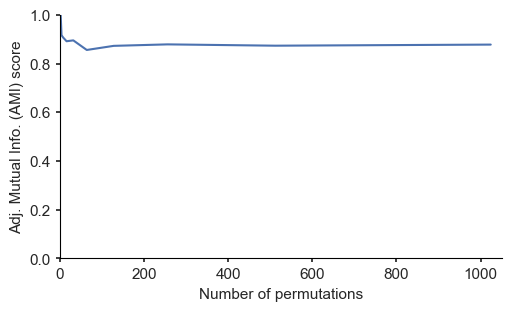

In [10]:
stability_df = pd.DataFrame(stability_dict.items(), columns=['log2(n_runs)', 'AMI'])
stability_df['n_runs'] = 2 ** (stability_df['log2(n_runs)'] + 1)
plt.figure(figsize=(5, 3))
sns.lineplot(x=stability_df['n_runs'], y=stability_df['AMI'])
plt.ylabel('Adj. Mutual Info. (AMI) score')
plt.ylim(0, 1)
plt.xlim(0, 1050)
plt.xlabel('Number of permutations')
plt.xscale('linear')
plt.savefig('FIGURES/final_clusters/stability_finalclusters.svg', bbox_inches='tight')
plt.show()

In [11]:
consensus_matrix = consensus_matrix(final_clusters)

In [12]:
# Applying k-means clustering to consensus matrix
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE).fit(consensus_matrix)
kmeans_df = pd.DataFrame({
    'Patient ID': consensus_matrix.index,
    'Cluster': kmeans.labels_})
kmeans_clusters = {}
for cluster in range(n_clusters):
    kmeans_clusters[f'Cluster_{cluster}'] = kmeans_df[kmeans_df['Cluster'] == cluster]['Patient ID'].tolist()

In [13]:
# Convert to .csv file for easier analysis later
pd.DataFrame.from_dict(kmeans_clusters, orient='index').to_csv('patient_clusters.csv')

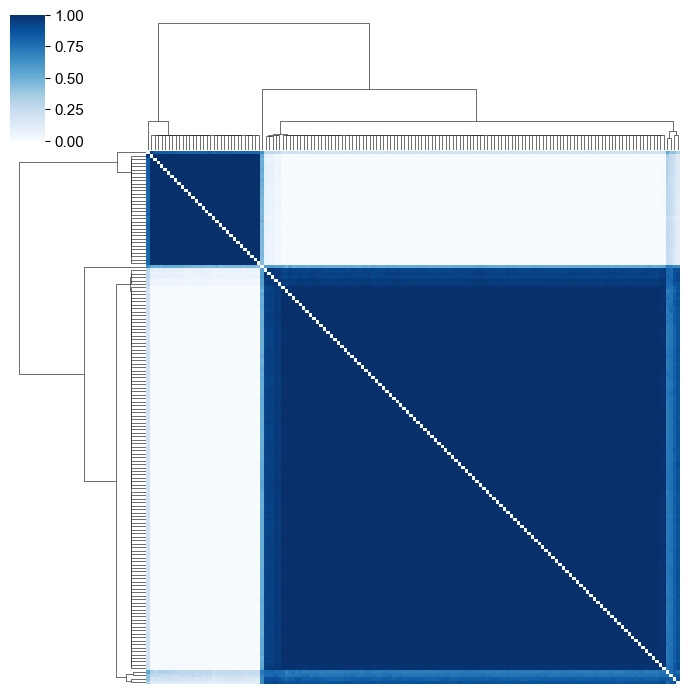

In [14]:
plt.rcParams.update(plt.rcParamsDefault)
rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica']})
# Applying hierarchical clustering to consensus matrix
cm = sns.clustermap(consensus_matrix, cmap='Blues', yticklabels=False, xticklabels=False, figsize=(7,7))
linkage_matrix = cm.dendrogram_row.linkage
cluster_assignments = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')
plt.savefig('FIGURES/final_clusters/consensus_final_clusters.svg', bbox_inches='tight')
plt.savefig('FIGURES/final_clusters/consensus_final_clusters.png', bbox_inches='tight')
plt.show()

patient_ids = consensus_matrix.index
hierarchical_clusters = {}
for cluster in range(1, n_clusters + 1):
    hierarchical_clusters[f'Cluster_{cluster-1}'] = [patient_ids[i] for i, assignment in enumerate(cluster_assignments) if assignment == cluster]

In [15]:
# Function to compare hierarchical clusters with K-means clusters
hierarchical_sets = {key: set(values) for key, values in hierarchical_clusters.items()}
kmeans_sets = {key: set(values) for key,values in kmeans_clusters.items()}
for h_key, h_set in hierarchical_sets.items():
    match_found = False
    for k_key, k_set in kmeans_sets.items():
        if h_set == k_set:
            print(f"Hierarchical {h_key} matches K-means {k_key}")
            match_found = True
            break
    if not match_found:
        print(f"Hierarchical {h_key} does not match any K-means cluster")

Hierarchical Cluster_0 matches K-means Cluster_0
Hierarchical Cluster_1 matches K-means Cluster_1


In [16]:
# Item consensus (only for two clusters)
def get_item_consensus(consensus_matrix: pd.DataFrame, ref_cluster_num: int):
    ref_cluster = hierarchical_clusters[f"Cluster_{ref_cluster_num}"]
    other_cluster = 0 if ref_cluster_num == 1 else 1
    item_consensus = {}
    for patient in consensus_matrix.columns:
        if patient in ref_cluster:
            cluster_matrix = consensus_matrix.loc[consensus_matrix.index.isin(ref_cluster), consensus_matrix.columns.isin(ref_cluster)]
            ref_cluster_avg = cluster_matrix[patient].mean()
            other_cluster_avg = 1 - ref_cluster_avg
        else:
            cluster_matrix = consensus_matrix.loc[~consensus_matrix.index.isin(ref_cluster), ~consensus_matrix.columns.isin(ref_cluster)]
            other_cluster_avg = cluster_matrix[patient].mean()
            ref_cluster_avg = 1 - other_cluster_avg
        item_consensus[patient] = {f"cluster{ref_cluster_num}": ref_cluster_avg, f"cluster{other_cluster}": other_cluster_avg}
    return item_consensus

In [17]:
item_consensus = get_item_consensus(consensus_matrix, 1)
sorted_dict = dict(sorted(item_consensus.items(), key=lambda item: item[1]['cluster0'], reverse=True))

In [18]:
sns.set_theme(style='ticks')
rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'savefig.format': 'svg',
    'savefig.dpi': 300,  # Still useful for rasterized elements
    'figure.dpi': 100,
    'figure.figsize': (3.5, 2.5),  # Approx. half-column width
    'figure.constrained_layout.use': True,
    'svg.fonttype': 'none',  # Keep text as editable text (not paths)
    'axes.spines.top': False,
    'axes.spines.right': False,
})

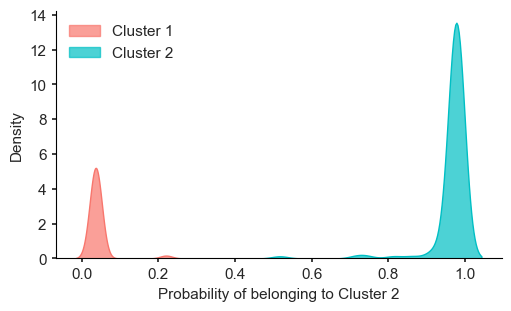

In [19]:
cluster_0_patients = hierarchical_clusters['Cluster_0']
cluster_1_patients = hierarchical_clusters['Cluster_1']

probabilities = []
groups = []
for patient, probs in sorted_dict.items():
    # Use probability of belonging to cluster1, so that patients from cluster 0 have a probability of 0
    if patient in cluster_0_patients:
        probabilities.append(probs['cluster1'])  
        groups.append('Cluster 0')
    elif patient in cluster_1_patients:
        probabilities.append(probs['cluster1'])
        groups.append('Cluster 1')

df = pd.DataFrame({'Probability': probabilities, 'Cluster': groups})
plt.figure(figsize=(5, 3))
palette = ["#F8766D", "#00BFC4"]
sns.kdeplot(data=df, x="Probability", palette=palette, hue="Cluster", 
            multiple="layer", fill=True, alpha=0.7)
plt.legend(labels=['Cluster 1', 'Cluster 2'], loc='upper left', 
           handles=[plt.Rectangle((0, 0), 1, 1, color=palette[0], alpha=0.7), 
                    plt.Rectangle((0, 0), 1, 1, color=palette[1], alpha=0.7)])
plt.xlabel("Probability of belonging to Cluster 2")
plt.ylabel("Density")
plt.savefig('FIGURES/final_clusters/item_consensus.svg', bbox_inches='tight')
plt.show()

### Comparing methylation and copy number data, based on cluster assignments

In [20]:
hierarchical_cluster0 = hierarchical_clusters['Cluster_0']
hierarchical_cluster1 = hierarchical_clusters['Cluster_1']

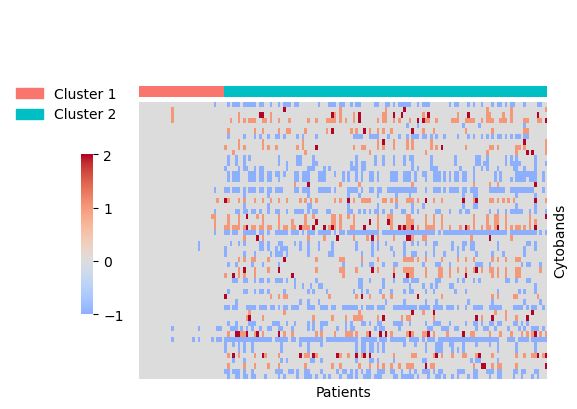

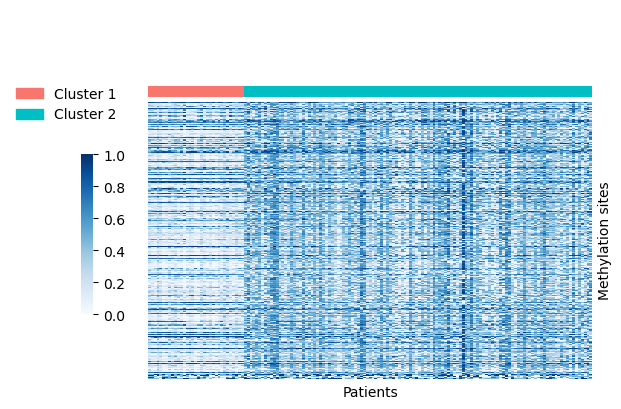

In [21]:
plt.rcParams.update(plt.rcParamsDefault)
import matplotlib.patches as mpatches
palette = ["#F8766D", "#00BFC4"]

# Get data from both methylation and CNA
CNA_file = pd.read_csv('TCGA_processed_data/CNA_processed.csv', index_col=0)
CNA_file['Cluster'] = None
for cluster_num, patients in hierarchical_clusters.items():
    cluster_label = int(cluster_num.split('_')[-1])
    CNA_file.loc[CNA_file.index.isin(patients), 'Cluster'] = cluster_label
CNA_data = CNA_file.sort_values(by='Cluster')

methylation_file = pd.read_csv('TCGA_processed_data/methylation_processed.csv', index_col=0)
methylation_file['Cluster'] = None
for cluster_num, patients in hierarchical_clusters.items():
    cluster_label = int(cluster_num.split('_')[-1])
    methylation_file.loc[methylation_file.index.isin(patients), 'Cluster'] = cluster_label
methylation_data = methylation_file.sort_values(by='Cluster')

# Plot heatmaps
clusters_CNA = CNA_data['Cluster'].unique()
color_mapping_CNA = dict(zip(clusters_CNA, palette))
cluster_colors_CNA = CNA_data['Cluster'].map(color_mapping_CNA)
cm_cna = sns.clustermap(data=CNA_data.drop(columns=['Cluster']).T, col_colors=cluster_colors_CNA, cmap='coolwarm', col_cluster=False, 
                        row_cluster=False, figsize=(6,4), center=0, xticklabels=False, yticklabels=False, cbar_pos=(0.1, 0.2, 0.02, 0.4))
cm_cna.ax_col_colors.set_yticks([])
plt.legend(labels=['Cluster 1', 'Cluster 2'], frameon=False, bbox_to_anchor=[4, 1.5],
           handles=[plt.Rectangle((0, 0), 1, 1, color=palette[0]), 
                    plt.Rectangle((0, 0), 1, 1, color=palette[1])])
cm_cna.ax_heatmap.set_xlabel('Patients')
cm_cna.ax_heatmap.set_ylabel('Cytobands')
plt.savefig('FIGURES/final_clusters/cna_heatmap.png', bbox_inches='tight')
plt.show()

clusters_methylation = methylation_data['Cluster'].unique()
color_mapping_methylation = dict(zip(clusters_methylation, palette))
cluster_colors_methylation = methylation_data['Cluster'].map(color_mapping_methylation)
cm_methyl = sns.clustermap(data=methylation_data.drop(columns=['Cluster']).T, col_colors=cluster_colors_methylation.rename(" "), cmap='Blues', col_cluster=False, 
                          row_cluster=False, figsize=(6, 4), xticklabels=False, yticklabels=False, cbar_pos=(0.1, 0.2, 0.02, 0.4), vmin=0, vmax=1)
cm_methyl.ax_col_colors.set_yticks([])
plt.legend(labels=['Cluster 1', 'Cluster 2'], frameon=False, bbox_to_anchor=[4, 1.5],
           handles=[plt.Rectangle((0, 0), 1, 1, color=palette[0]), 
                    plt.Rectangle((0, 0), 1, 1, color=palette[1])])
cm_methyl.ax_heatmap.set_xlabel('Patients')
cm_methyl.ax_heatmap.set_ylabel('Methylation sites')
plt.savefig('FIGURES/final_clusters/methyl_heatmap.png', bbox_inches='tight')
plt.show()

In [22]:
rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'legend.fontsize': 12,
    'legend.frameon': False,
    'savefig.format': 'svg',
    'savefig.dpi': 300,  # Still useful for rasterized elements
    'figure.dpi': 100,
    'figure.figsize': (3.5, 2.5),  # Approx. half-column width
    'figure.constrained_layout.use': True,
    'svg.fonttype': 'none',  # Keep text as editable text (not paths)
    'axes.spines.top': False,
    'axes.spines.right': False,
})

0 vs. 1: p = 2.64e-15
0 vs. 1: p = 9.84e-18


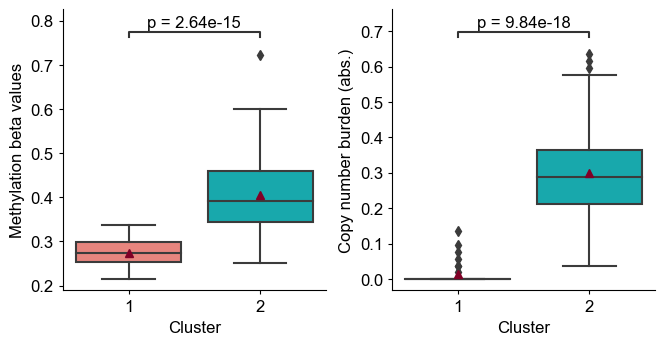

In [23]:
palette = ["#F8766D", "#00BFC4"]
from scipy.stats import mannwhitneyu
methyl_means = methylation_data.drop(columns='Cluster').mean(numeric_only=True, axis=1)
methyl_means = pd.DataFrame({"Methylation": methyl_means, "Cluster": methylation_data["Cluster"].values})

cna_means = CNA_data.abs().drop(columns='Cluster').mean(numeric_only=True, axis=1)
cna_means = pd.DataFrame({"CNA": cna_means, "Cluster": CNA_data["Cluster"].values})

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
pairs = [(0, 1)]
sns.boxplot(data=methyl_means, x='Cluster', y='Methylation', showmeans=True, ax=ax[0], palette=palette, meanprops={"markerfacecolor": "#800026","markeredgecolor": "#800026"})
ax[0].set_ylabel('Methylation beta values')
ax[0].set_xticklabels([1, 2])
mgroup0 = methyl_means.loc[methyl_means["Cluster"] == 0, "Methylation"]
mgroup1 = methyl_means.loc[methyl_means["Cluster"] == 1, "Methylation"]
mstat, mp_value = mannwhitneyu(mgroup0, mgroup1)
mannotator = Annotator(ax[0], pairs, data=methyl_means, x='Cluster', y='Methylation')
mannotator.configure(test=None, text_format="simple", loc="inside")
mannotator.set_custom_annotations([f"p = {mp_value:.2e}"])
mannotator.annotate()

sns.boxplot(data=cna_means, x='Cluster', y='CNA', showmeans=True, ax=ax[1], palette=palette, meanprops={"markerfacecolor": "#800026","markeredgecolor": "#800026"})
ax[1].set_ylabel('Copy number burden (abs.)')
ax[1].set_xticklabels([1, 2])
cnagroup0 = cna_means.loc[cna_means["Cluster"] == 0, "CNA"]
cnagroup1 = cna_means.loc[cna_means["Cluster"] == 1, "CNA"]
cnastat, cnap_value = mannwhitneyu(cnagroup0, cnagroup1)
cnaannotator = Annotator(ax[1], pairs, data=cna_means, x='Cluster', y='CNA')
cnaannotator.configure(test=None, text_format="simple", loc="inside")
cnaannotator.set_custom_annotations([f"p = {cnap_value:.2e}"])
cnaannotator.annotate()

plt.tight_layout()
plt.savefig('FIGURES/final_clusters/methyl_cna_comparison.svg', bbox_inches='tight')
plt.show()